# Differential expression analysis

Today we are going to learn how to perform differential expression analysis on aging bulk RNA-seq datasets. For this lesson we prepared longitudinal RNA-seq data on aged human fibroblasts from {cite:t}`fleischer2018predicting`. This data is already processed; therefore we can skip a large part devoted to raw read processing and mapping ({numref}`de_workflow`) and start with a table of counts.  

```{figure} figs/TitleFigure.png
:name: de_workflow

A typical workflow for DE analysis.
```

## Preparing the data 

We will start with uploading the expression data table together with the meta file containing a brief sample description (age, ethnicity). While the original study includes both male and female profiles, we selected only the male ones for simplicity of further analysis. Processed files (*data_fibroblasts.csv* and *meta_fibroblasts.csv*) are available here: https://www.dropbox.com/scl/fo/ma7zolpu62s9lcybjlc4h/AFIw64bZXGLumx9QJCfzCD4?rlkey=3agxgg1g91ehqa3rpordereyl&dl=0

In [1]:
import numpy as np
import pandas as pd
from collections import Counter

path_data = "data/data_fibroblasts.csv" # change this with your actual path to data file
raw_counts = pd.read_csv(path_data, index_col=0)

Check the number of gene features and the number of samples available in the dataset:

In [2]:
print("Number of genes:", raw_counts.shape[0])
print("Number of samples:", raw_counts.shape[1])

Number of genes: 29744
Number of samples: 99


This table includes expression profiles of 99 samples with 29744 genes detected. However, some of these genes can have zero expression values across samples. We will filter them out:

In [3]:
raw_counts = raw_counts.loc[~(raw_counts==0).all(axis=1)]
raw_counts.shape

(24033, 99)

Then we will load the meta file with sample descriptions:

In [4]:
path_meta = "data/meta_fibroblasts.csv" # change this with your actual path to meta file
meta = pd.read_csv(path_meta, index_col=0)
meta.head(10)

,Age,Ethnicity
SRX4022456,1,Asian
SRX4022457,12,Caucasian
SRX4022459,25,Caucasian
SRX4022461,26,Caucasian
SRX4022463,28,Caucasian
SRX4022464,29,Caucasian
SRX4022465,29,Caucasian
SRX4022466,30,Caucasian
SRX4022468,30,Caucasian
SRX4022469,30,Caucasian


Let's check the age range of our samples using the information from the first column of the *meta*:

In [5]:
print("Minimal age:", min(meta.Age.values))
print("Maximal age:", max(meta.Age.values))

Minimal age: 1
Maximal age: 96


To perform further analysis we will divide samples into age groups with a step = 10 years.

In [6]:
bins = pd.cut(meta["Age"], np.arange(0, meta["Age"].max() + 10, 10), right=False)
meta["AgeBins"] = bins.cat.codes  # index of the age group: 0 for [0, 10), 1 for [10, 20), ...
meta["AgeRanges"] = bins.astype(str)
meta.head()

,Age,Ethnicity,AgeBins,AgeRanges
SRX4022456,1,Asian,0,"[0, 10)"
SRX4022457,12,Caucasian,1,"[10, 20)"
SRX4022459,25,Caucasian,2,"[20, 30)"
SRX4022461,26,Caucasian,2,"[20, 30)"
SRX4022463,28,Caucasian,2,"[20, 30)"


## Setting up DESeq2

We will run DESeq2 with [InMoose](https://inmoose.readthedocs.io), a Python port of the DESeq2 R package. InMoose does not implement the likelihood ratio test (LRT) yet, so the hidden cell below adds a port of the corresponding DESeq2 function to it.

In [7]:
# Likelihood ratio test for InMoose: a port of nbinomLRT() from the DESeq2 R package
import numpy as np
import pandas as pd
from scipy.stats import chi2
import inmoose.deseq2.core as _core
import inmoose.deseq2.lrt as _lrt
import inmoose.deseq2.outliers as _outliers
from inmoose.deseq2.fitNbinomGLMs import fitNbinomGLMs
from inmoose.deseq2.misc import buildDataFrameWithNACols, buildMatrixWithNACols
from inmoose.deseq2.wald import calculateCooksDistance, recordMaxCooks


def nbinomLRT(obj, full=None, reduced=None, betaTol=1e-8, maxit=100, useOptim=True,
              quiet=False, useQR=True, minmu=0.5, type_="DESeq2"):
    """Likelihood ratio test for NB GLMs: port of DESeq2::nbinomLRT (type="DESeq2")."""
    if type_ != "DESeq2":
        raise NotImplementedError("only type_='DESeq2' is supported")
    if "dispersion" not in obj.var:
        raise ValueError("testing requires dispersion estimates, first call estimateDispersions()")
    if reduced is None:
        raise ValueError('provide a reduced design for the LRT, e.g. reduced="~1"')
    if full is None:
        full = obj.design
    df = full.shape[1] - reduced.shape[1]
    if df < 1:
        raise ValueError("less than one degree of freedom, perhaps full and reduced models are not in the correct order")

    if not obj.var.type.filter("results").empty:
        obj = obj.removeResults()
    if "allZero" not in obj.var:
        obj = obj.getBaseMeansAndVariances()
    obj.modelMatrixType = "standard"
    hasIntercept = 0 in [len(t.factors) for t in obj.design.design_info.terms]
    objNZ = obj[:, ~obj.var["allZero"]]

    fit_args = dict(betaTol=betaTol, maxit=maxit, useOptim=useOptim, useQR=useQR,
                    warnNonposVar=False, minmu=minmu)
    fullModel = fitNbinomGLMs(objNZ, modelMatrix=full, renameCols=hasIntercept, **fit_args)
    reducedModel = fitNbinomGLMs(objNZ, modelMatrix=reduced, modelFormula=reduced,
                                 renameCols=False, **fit_args)

    LRTStatistic = 2 * (np.asarray(fullModel["logLike"]) - np.asarray(reducedModel["logLike"]))
    LRTPvalue = chi2.sf(LRTStatistic, df)
    modelMatrix = fullModel["modelMatrix"]
    H = fullModel["hat_diagonals"]
    mu = fullModel["mu"]

    objNZ.layers["mu"] = mu
    obj.layers["mu"] = buildMatrixWithNACols(mu, obj.var["allZero"])
    obj.layers["H"] = buildMatrixWithNACols(H, obj.var["allZero"])
    obj.dispModelMatrix = modelMatrix
    cooks = calculateCooksDistance(objNZ, H, modelMatrix)
    maxCooks = recordMaxCooks(obj.design, obj.obs, modelMatrix, cooks, objNZ.n_vars)
    obj.layers["cooks"] = buildMatrixWithNACols(cooks, obj.var["allZero"])

    obj.betaPrior = False
    obj.betaPriorVar = np.full(modelMatrix.shape[1], 1e6)
    obj.modelMatrix = modelMatrix
    obj.reducedModelMatrix = reduced
    obj.test = "LRT"

    names = modelMatrix.design_info.column_names
    betaMatrix = fullModel["betaMatrix"]
    betaMatrix.index = objNZ.var_names
    betaSE = fullModel["betaSE"]
    betaSE.index = objNZ.var_names
    betaSE.columns = [f"SE_{n}" for n in names]
    resultsDF = pd.concat([betaMatrix, betaSE], axis=1)
    resultsDF["LRTStatistic"] = LRTStatistic
    resultsDF["LRTPvalue"] = LRTPvalue
    resultsDF["fullBetaConv"] = fullModel["betaConv"]
    resultsDF["reducedBetaConv"] = reducedModel["betaConv"]
    resultsDF["betaIter"] = fullModel["betaIter"]
    resultsDF["deviance"] = -2 * np.asarray(fullModel["logLike"])
    resultsDF["maxCooks"] = maxCooks
    LRTResults = buildDataFrameWithNACols(resultsDF, obj.var["allZero"])
    LRTResults.index = obj.var_names

    new_var = pd.concat([obj.var, LRTResults], axis=1)
    for c in obj.var.columns:
        new_var.type[c] = obj.var.type[c]
        new_var.description[c] = obj.var.description[c]
    obj.var = new_var
    for c in LRTResults.columns:
        obj.var.type[c] = "results"
    comparison = f"'{full.design_info.describe()}' vs '{reduced.design_info.describe()}'"
    for c, n in zip(betaMatrix.columns, names):
        obj.var.description[c] = f"log2 fold change (MLE): {n}"
    for c, n in zip(betaSE.columns, names):
        obj.var.description[c] = f"standard error: {n}"
    obj.var.description["LRTStatistic"] = f"LRT statistic: {comparison}"
    obj.var.description["LRTPvalue"] = f"LRT p-value: {comparison}"
    obj.var.description["fullBetaConv"] = "convergence of betas for full model"
    obj.var.description["reducedBetaConv"] = "convergence of betas for reduced model"
    obj.var.description["betaIter"] = "iterations for betas for full model"
    obj.var.description["deviance"] = "deviance of the full model"
    obj.var.description["maxCooks"] = "maximum Cook's distance for column"
    return obj


# plug the port into InMoose (DESeq() and the outlier-refitting step call nbinomLRT)
_lrt.nbinomLRT = _core.nbinomLRT = _outliers.nbinomLRT = nbinomLRT

In [8]:
from inmoose.deseq2 import DESeqDataSet, DESeq
from inmoose.deseq2.vst import varianceStabilizingTransformation

In [9]:
class DESeq2():
    def __init__(self, counts, meta, design):
        # InMoose expects samples in rows and genes in columns
        self.raw_counts = counts.T.round().astype(int)
        self.meta_raw = meta
        self.meta = meta.astype("category")
        self.design = design

    def create_deseq_object(self):
        self.dds = DESeqDataSet(self.raw_counts, clinicalData=self.meta, design=self.design)

    def normalization(self):
        self.dds = self.dds.estimateSizeFactors()
        norm_counts = pd.DataFrame(self.dds.counts(normalized=True),
                                   index=self.raw_counts.index, columns=self.raw_counts.columns)
        return norm_counts.T

    def transformation(self):
        mat = varianceStabilizingTransformation(self.dds, blind=True)
        return pd.DataFrame(mat.X, index=self.raw_counts.index, columns=self.raw_counts.columns).T

    def LRT_testing(self):
        self.dds = DESeq(self.dds, test="LRT", reduced="~1", quiet=True)
        res = pd.DataFrame(self.dds.results())
        return res.rename(columns={"adj_pvalue": "padj"})

    def clustering(self, cluster_mat):
        return degPatterns(cluster_mat, self.meta_raw, time="AgeBins")

## Normalization

Specify a design formula for statistical testing with DESeq2 (it is important to put the factor of interest at the end of the formula!):

In [10]:
design = "~AgeBins"
d = DESeq2(raw_counts, meta, design)

Initialize a DESeq2 object with our data:

In [11]:
d.create_deseq_object()

Perform DESeq2 normalization:

In [12]:
ncounts = d.normalization()

Then transform the data using the variance stabilizing transformation (VST) to get rid of heteroskedasticity:

In [13]:
vst_mat = d.transformation()

## Quality control

Before differential analysis we will explore the similarity of the samples in the age groups.

### Principal Component Analysis

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [15]:
x = np.transpose(vst_mat.values)
x = StandardScaler().fit_transform(x)

In [16]:
pca = PCA(n_components=2, random_state=0)

In [17]:
principalComponents = pca.fit_transform(x)

In [18]:
principalDf = pd.DataFrame(data = principalComponents, columns = ['PC1', 'PC2'])

In [19]:
pcdf = pd.concat([principalDf.set_index(meta.index), meta], axis = 1)

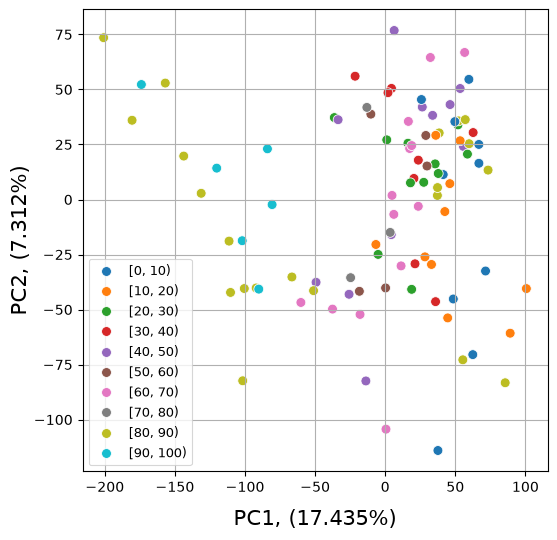

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.set_context("paper", font_scale=1.5)
age_order = meta.sort_values("AgeBins")["AgeRanges"].unique()
sns.scatterplot(data=pcdf, x="PC1", y="PC2", hue="AgeRanges", hue_order=age_order, s = 50)

var_pc1 = (pca.explained_variance_ratio_[0]*100).round(3)
var_pc2 = (pca.explained_variance_ratio_[1]*100).round(3)
plt.xlabel('PC1, ('+ var_pc1.astype(str) + "%)", fontsize = 15, labelpad = 10)
plt.ylabel('PC2, ('+ var_pc2.astype(str) + "%)", fontsize = 15, labelpad = 2)

plt.legend(fontsize=9)

ax.grid()

```{admonition} Exercise 1
:class: dropdown
Perform PCA on the top 500 most variable genes in the dataset (1 point).
```

## Statistical testing

Run the Likelihood Ratio Test (LRT) available in the DESeq2 package:

In [21]:
%%capture
res = d.LRT_testing()

Sort genes by the adjusted p-value:

In [22]:
res = res.sort_values(by=['padj', 'pvalue'], kind='stable')

Retrieve all the genes satisfying the p-value cut-off criterion $P<0.05$:

In [23]:
sig = res[res['padj'] < 0.05]

Check the number of significant genes:

In [24]:
print("Number of DE genes:", sig.shape[0])

Number of DE genes: 8447


```{admonition} Exercise 2
:class: dropdown
Determine the number of up- and down-regulated genes in the analysis (0.5 points). Investigate the top 10 DE genes from the up and down lists. Do they have any established connection with aging? If yes, support your claim with some references and a short description of their functions (1.5 points). 
```

## Gene clustering

To perform gene clustering we will select only a subset of significant genes, let's say the 1800 most significant features:

In [25]:
ngenes = 1800

In [26]:
cluster_mat = vst_mat.loc[sig.head(ngenes).index]

Perform gene clustering with *degPatterns*, a Python port of the function from the DEGreport R package (the code is hidden in the cell below):

In [27]:
# degPatterns(): a port of the gene-pattern clustering from the DEGreport R package
import numpy as np
import pandas as pd


def _kendall_dist(m):
    """(1 - Kendall tau-b)^2 between rows of m, computed like R's cor(method="kendall")."""
    i, j = np.triu_indices(m.shape[1], k=1)
    signs = np.sign(m[:, j] - m[:, i])
    s = 2 * signs @ signs.T                   # sum over all ordered pairs, as in R
    sd = np.sqrt(np.diag(s))
    tau = np.clip(s / (sd[:, None] * sd[None, :]), -1, 1)
    np.fill_diagonal(tau, 1.0)
    return (1 - tau) ** 2


def _diana_banner(d):
    """Divisive analysis (DIANA); port of splyt() from R's cluster package.
    Returns the banner order (0-based object indices) and banner heights."""
    nn = d.shape[0]
    kwan = [0] * (nn + 1)
    ban = [0.0] * (nn + 1)
    ner = list(range(nn + 1))  # 1-based positions -> 1-based objects
    kwan[1] = nn
    cs = d.max()
    ja, nclu = 1, 1

    def block(a, b):  # sequential row sums of d[a, b], summed in the same order as the C code
        return np.cumsum(d[np.ix_(a, b)], axis=1)[:, -1]

    while True:
        jb = ja + kwan[ja] - 1
        jma = jb
        if kwan[ja] == 2:
            kwan[ja] = kwan[jb] = 1
            ban[jb] = d[ner[ja] - 1, ner[jb] - 1]
        else:
            idx = np.array(ner[ja:jb + 1]) - 1
            lndsd = ja + int(np.argmax(block(idx, idx)))
            kwan[ja] -= 1
            kwan[jb] = 1
            if jb != lndsd:
                lchan = ner[lndsd]
                ner[lndsd:jb] = ner[lndsd + 1:jb + 1]
                ner[jb] = lchan
            splyn = 0
            jma = jb - 1
            while True:
                splyn += 1
                rest = jma - ja
                rem = np.array(ner[ja:jma + 1]) - 1
                spl = np.array(ner[jma + 1:jb + 1]) - 1
                dyff = block(rem, rem) / rest - block(rem, spl) / splyn
                k = int(np.argmax(dyff))
                jmb = jma + 1
                if dyff[k] <= 0:
                    break
                jaway = ja + k
                if jma != jaway:
                    lchan = ner[jaway]
                    ner[jaway:jma] = ner[jaway + 1:jma + 1]
                    ner[jma] = lchan
                for lxx in range(jmb, jb + 1):
                    if ner[lxx - 1] < ner[lxx]:
                        break
                    ner[lxx - 1], ner[lxx] = ner[lxx], ner[lxx - 1]
                kwan[ja] -= 1
                kwan[jma] = kwan[jmb] + 1
                kwan[jmb] = 0
                jma -= 1
                jmb = jma + 1
                if jma == ja:
                    break
            if ner[ja] >= ner[jmb]:  # switch the two parts when necessary
                lxxa = ja
                for lgrb in range(jmb, jb + 1):
                    lxxa += 1
                    lchan = ner[lgrb]
                    lxg = -1
                    for ll in range(lxxa, lgrb + 1):
                        lxf = lgrb - ll + lxxa
                        lxg = lxf - 1
                        ner[lxf] = ner[lxg]
                    ner[lxg] = lchan
                llq = kwan[jmb]
                kwan[jmb] = 0
                jma = ja + jb - jma - 1
                jmb = jma + 1
                kwan[jmb] = kwan[ja]
                kwan[ja] = llq
            if nclu == 1:
                ban[jmb] = cs
            else:
                idx = np.array(ner[ja:jb + 1]) - 1
                ban[jmb] = d[np.ix_(idx, idx)].max()
        nclu += 1
        if nclu >= nn:
            break
        # move on to the next cluster that still has to be split
        if jb != nn:
            while True:
                ja += kwan[ja]
                if ja > nn or kwan[ja] > 1:
                    break
            if ja <= nn:
                continue
        ja = 1
        while kwan[ja] <= 1:
            ja += kwan[ja]
            if ja > nn:
                ja = 1
    return np.array(ner[1:]) - 1, np.array(ban[1:])


def _divisive_coef(ban):
    """Port of bncoef() from R's cluster package."""
    n = len(ban)
    sup = max(ban[1:])
    cf = 0.0
    for k in range(n):
        syze = min(ban[max(k, 1)], ban[min(k + 1, n - 1)])
        cf += 1.0 - syze / sup
    return cf / n


def degPatterns(ma, metadata, time, minc=15):
    """Python port of DEGreport::degPatterns() with its default settings
    (summarize="merge", col=NULL, scale=TRUE, reduce=FALSE, consensusCluster=FALSE)."""
    groups = metadata.loc[ma.columns, time]
    levels = sorted(groups.unique())
    # mean expression of every gene within each group of samples
    counts_group = pd.DataFrame({g: ma.loc[:, groups == g].mean(axis=1) for g in levels})
    norm_sign = counts_group.sub(counts_group.mean(axis=1), axis=0).div(counts_group.std(axis=1), axis=0)
    # divisive hierarchical clustering on the Kendall distance between group profiles
    order, ban = _diana_banner(_kendall_dist(counts_group.to_numpy()))
    dc = _divisive_coef(ban)
    # cut the tree at height = divisive coefficient: a new cluster starts wherever the banner exceeds dc
    run = np.cumsum(ban > dc)
    label_of = np.empty(len(order), dtype=int)
    label_of[order] = run
    # number clusters in order of the genes' appearance (as R's cutree does)
    ids = {}
    cluster = np.array([ids.setdefault(lab, len(ids) + 1) for lab in label_of])
    sizes = pd.Series(cluster).value_counts()
    keep = np.isin(cluster, sizes.index[sizes > minc])
    content = pd.DataFrame({"genes": ma.index[keep], "cluster": cluster[keep]})
    first = metadata.loc[ma.columns].drop_duplicates(subset=time).set_index(time)
    clust_data = (norm_sign.loc[content["genes"]]
                  .rename_axis(index="genes", columns=time)
                  .stack().rename("value").reset_index()
                  .merge(content, on="genes")
                  .join(first, on=time))
    return content, clust_data

In [28]:
%%capture
content, clust_data = d.clustering(cluster_mat)

The function above returned 15 clusters consisting of more than 15 genes that are similar in their expression patterns.

In [29]:
Counter(content.cluster.tolist())

Counter({4: 471,
         2: 415,
         1: 248,
         6: 186,
         3: 110,
         7: 56,
         14: 42,
         20: 40,
         12: 37,
         5: 36,
         9: 35,
         8: 20,
         10: 18,
         11: 16,
         17: 16})

We can use the content of the *clust_data* dataframe to explore the obtained expression patterns and plot them with the seaborn library:

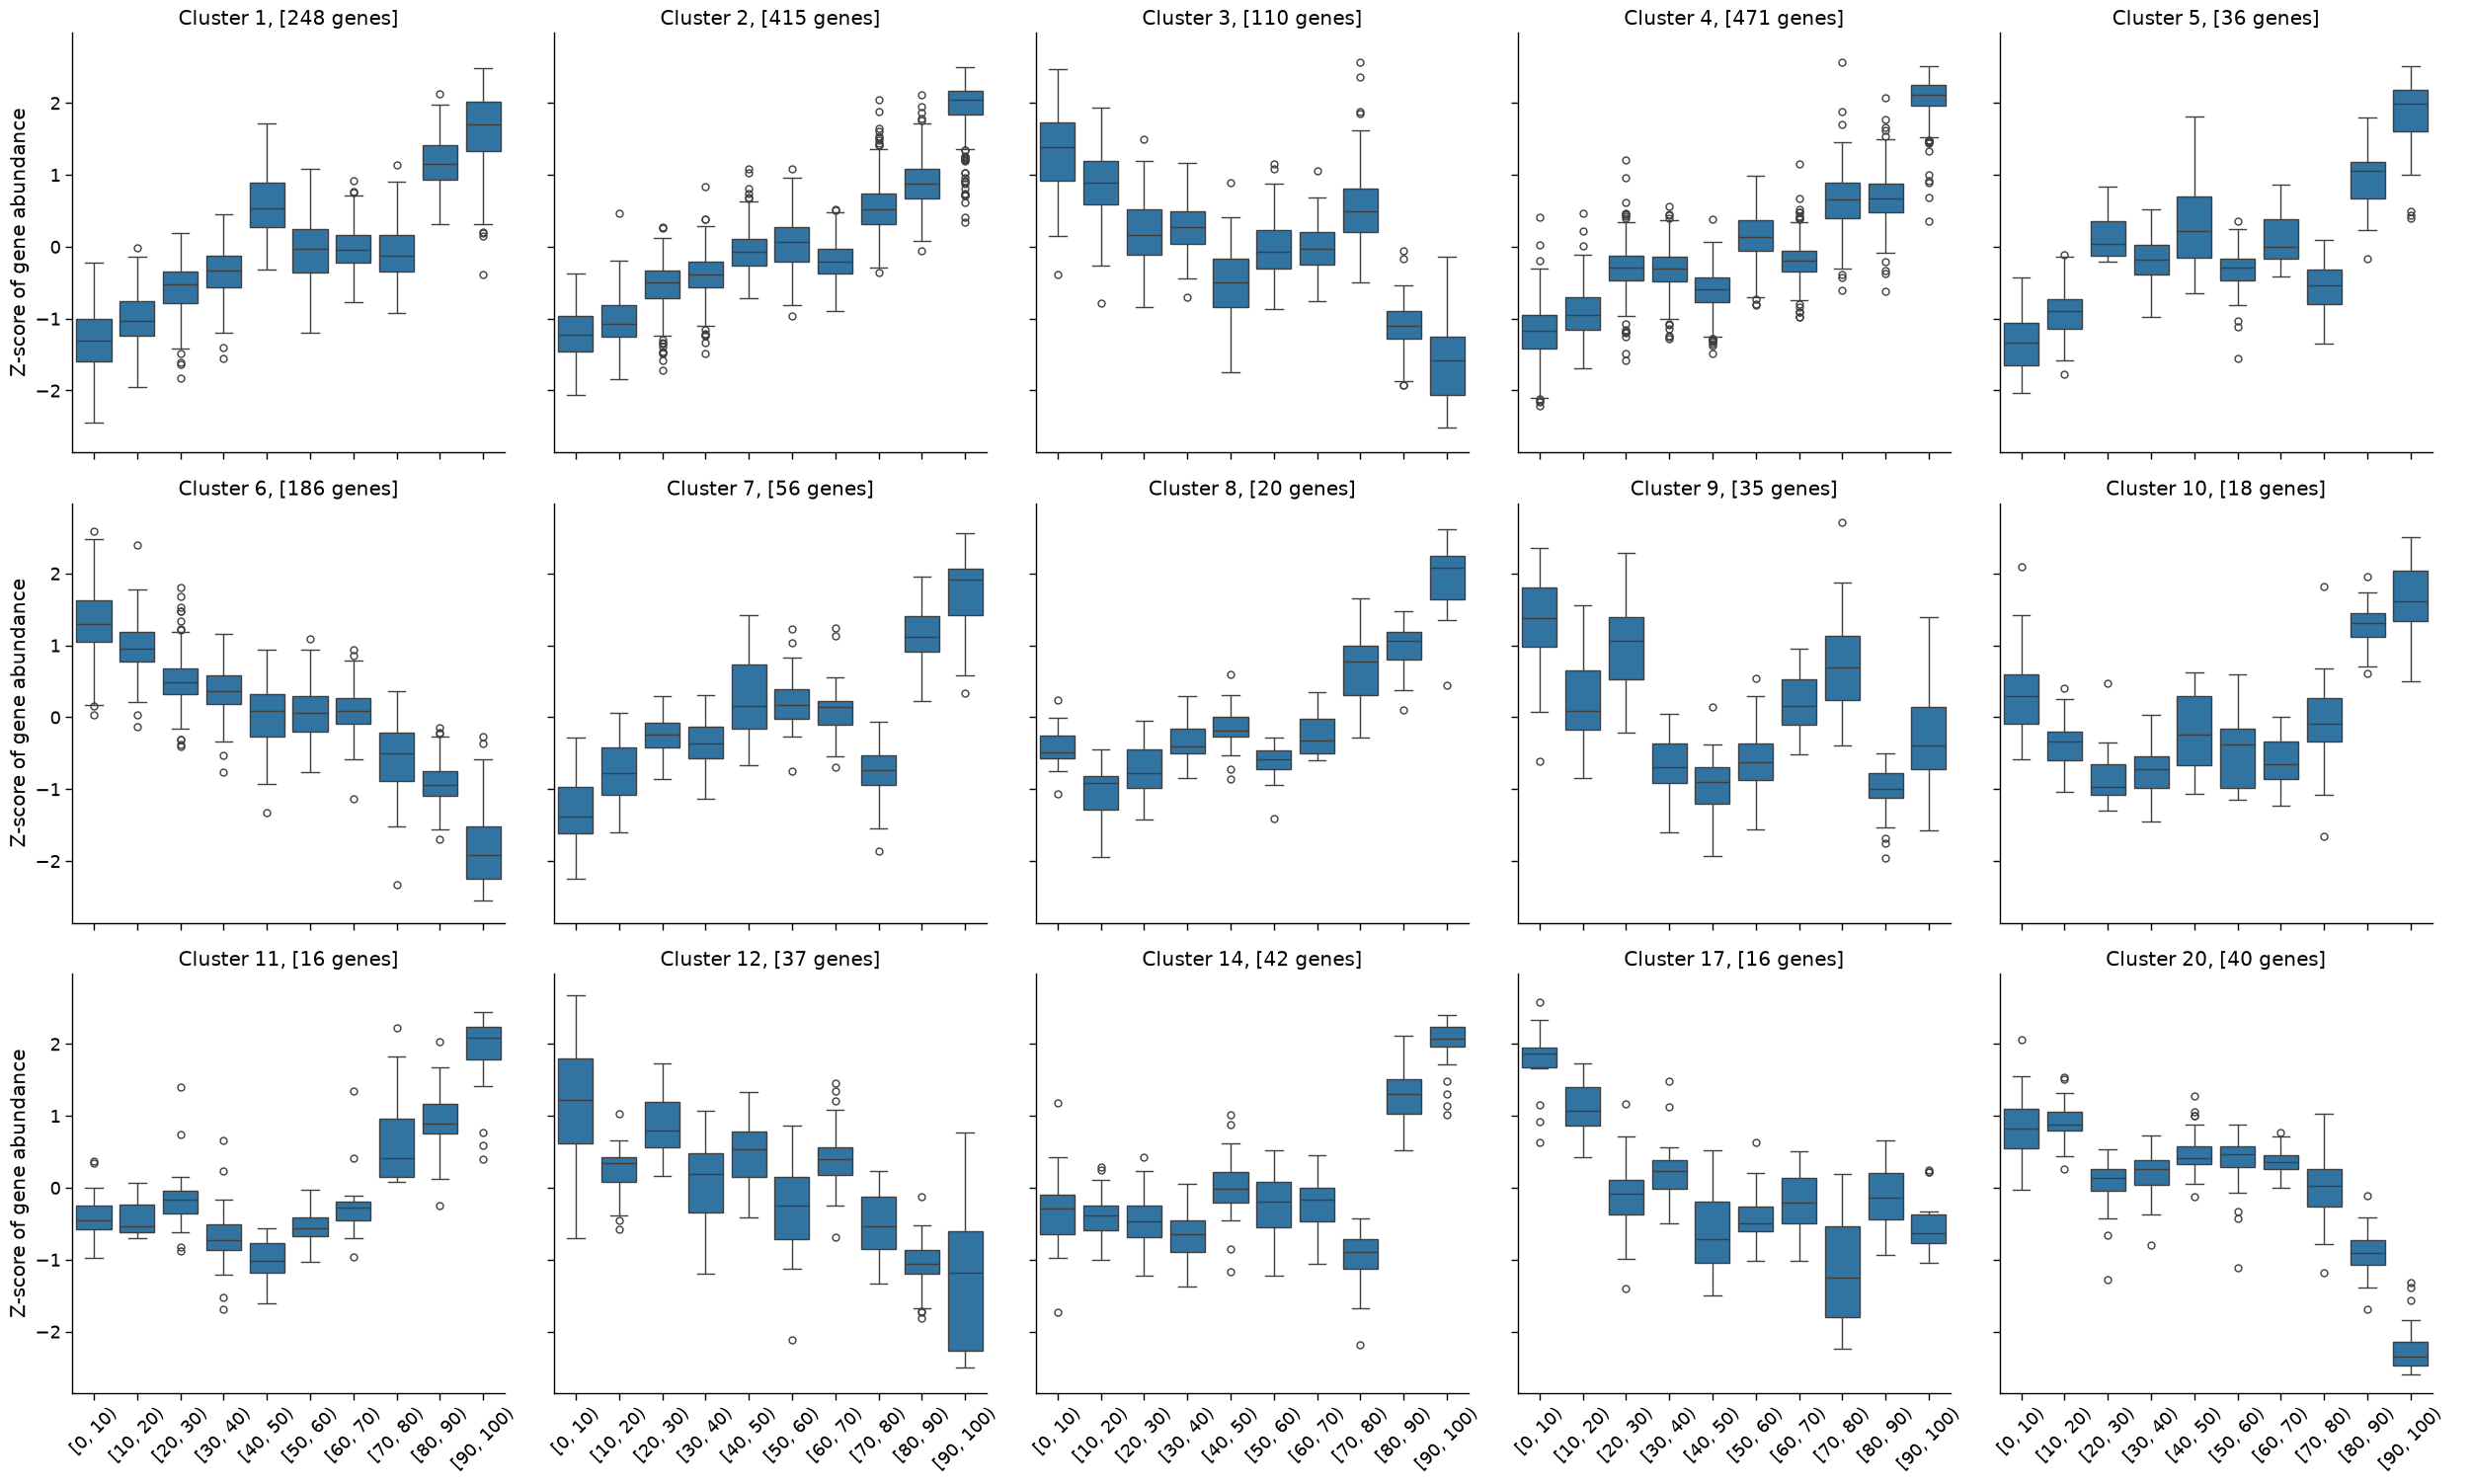

In [30]:
g = sns.catplot(data=clust_data, 
                x='AgeRanges', 
                y='value', 
                col='cluster', 
                kind='box', 
                col_wrap=5, 
                col_order=sorted(content.cluster.unique()),
                order= np.unique(clust_data.AgeRanges.values))
g.set_axis_labels("", "Z-score of gene abundance")
g.tick_params(axis='x', rotation=45)
axes = g.axes.flatten()
gene_number = Counter(content.cluster.tolist())
cluster_ids = sorted(gene_number)
for i in range(len(axes)):
    axes[i].set_title("Cluster " + str(cluster_ids[i]) + ", [" + str(gene_number[cluster_ids[i]]) + " genes]")

## GO analysis

In [31]:
import gseapy
from gseapy import dotplot

Select a cluster for the GO analysis:

In [32]:
cluster_id = 2

In [33]:
enr = gseapy.enrichr(gene_list = list(content[content['cluster'] == cluster_id].genes.values),
                     background = res.index.values,
                     gene_sets=['GO_Biological_Process_2021', 
                                'GO_Cellular_Component_2021', 
                                'GO_Molecular_Function_2021'],
                     organism='human',
                     outdir=None)

For simplicity, we will drop non-informative columns and keep the terms possessing 'Adjusted P-value' < 0.05:

In [34]:
enr_res = enr.results.drop(columns=["Old P-value", "Old adjusted P-value", "Old Adjusted P-value"], errors="ignore")
enr_res = enr_res[enr_res['Adjusted P-value'] < 0.05]

To visualize the top 5 enrichment terms from each set (Biological Process, Cellular Component, Molecular Function), we can apply the *dotplot* function from gseapy:

<Axes: title={'center': 'GO analysis'}, xlabel='Gene_set'>

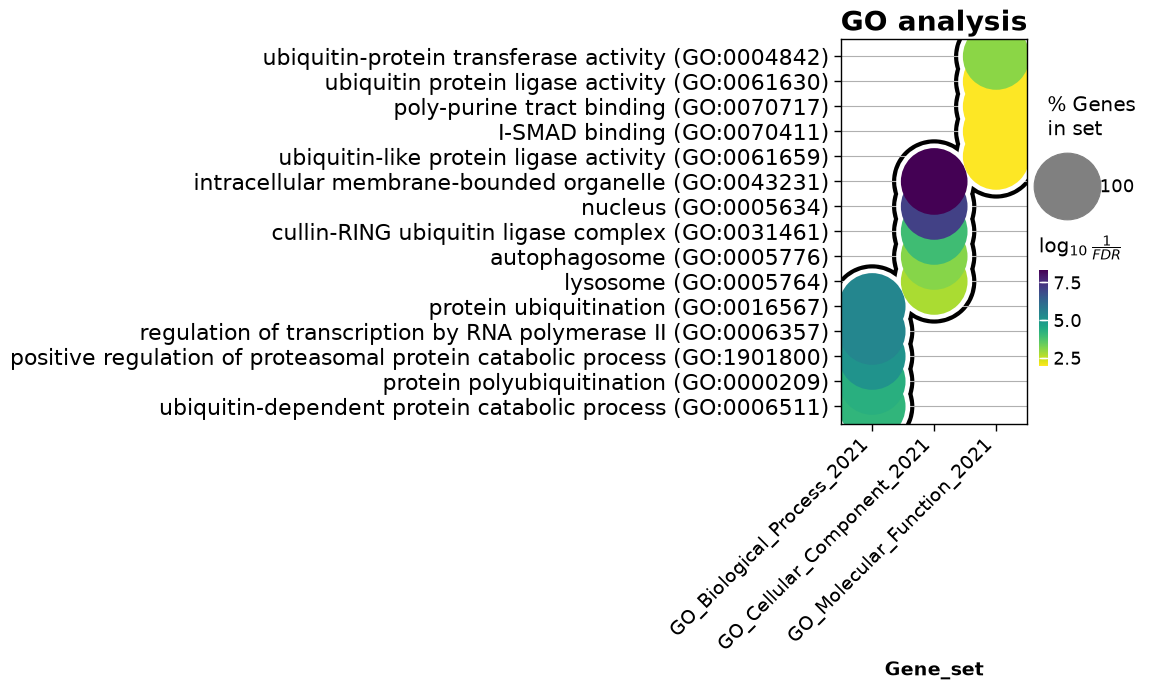

In [35]:
dotplot(enr_res,
              column="Adjusted P-value",
              x='Gene_set',
              size=10,
              top_term=5,
              figsize=(3,5),
              title = "GO analysis",
              xticklabels_rot=45, 
              show_ring=True, 
              marker='o',
             )

 ```{admonition} Exercise 2
:class: dropdown
Perform GO analysis on genes from clusters 1, 3, 4 and prepare figures showing the top 5 enriched terms (if possible) (1 point). 
```

```{admonition} Exercise 3
:class: dropdown
Perform enrichment analysis on genes from clusters 1, 3, 4 using aging-related databases: 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up' and 'GTEx_Aging_Signatures_2021' (1 point).
```

## Learn more

* Detailed [manual](https://hbctraining.github.io/DGE_workshop_salmon/schedule/) on differential expression analysis with DESeq2 in R
* [RNA-seq analysis](https://pypi.org/project/RNAlysis/) with Python 
* Omics Data Analysis course at Skoltech (MA060061)

## Credits

This notebook was prepared by [Dmitrii Smirnov](https://crei.skoltech.ru/cls/people/dmitriismirnov).

## References

```{bibliography}
:style: plain
:filter: docname in docnames
```